In [3]:
!wget -O /content/development.mp4 https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/1080/Big_Buck_Bunny_1080_10s_1MB.mp4

--2026-09-19 14:29:28--  https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/1080/Big_Buck_Bunny_1080_10s_1MB.mp4
Resolving test-videos.co.uk (test-videos.co.uk)... 172.67.192.184, 104.21.60.65, 2606:4700:3036::6815:3c41, ...
Connecting to test-videos.co.uk (test-videos.co.uk)|172.67.192.184|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1046987 (1022K) [video/mp4]
Saving to: ‘/content/development.mp4’

/content/developmen 100%[===================>]   1022K  --.-KB/s    in 0.1s    

2026-09-19 14:29:28 (7.91 MB/s) - ‘/content/development.mp4’ saved [1046987/1046987]



In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path
from time import perf_counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Video, display

In [ ]:
VIDEO_PATH = Path("/content/development.mp4")

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Vision/vision_unit_03/outputs/day_01"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_VIDEO_PATH = (OUTPUT_DIR / "opencv_roundtrip.mp4")


print("OpenCV version:", cv2.__version__)
print("Input video:", VIDEO_PATH)
print("Output video:", OUTPUT_VIDEO_PATH)

OpenCV version: 5.0.0
Input video: /content/development.mp4
Output video: /content/drive/MyDrive/Vision/vision_unit_03/outputs/day_01/opencv_roundtrip.mp4


**Read video metadata**

In [8]:
def decode_fourcc(raw_fourcc):
    raw_fourcc = int(raw_fourcc)
    
    characters = [
        chr(
        (raw_fourcc >> (8 * index)) & 0xFF
    ) for index in range(4)
    ]
    
    return "".join(characters).strip("\x00")

In [9]:
def read_video_metadata(video_path):
    capture = cv2.VideoCapture(str(video_path))
    
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    source_fps = float(capture.get(cv2.CAP_PROP_FPS))
    reported_frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    
    raw_fourcc = capture.get(cv2.CAP_PROP_FOURCC)
    
    try:
        backend = capture.getBackendName()
    except Exception:
        backend = "unknown"
        
    capture.release()
    
    if width <= 0 or height <= 0:
        raise RuntimeError("Invalid video resolution")

    if (not np.isfinite(source_fps) or source_fps <= 0):
        raise RuntimeError("Invalid source FPS")
    
    duration_seconds = (
        reported_frame_count / source_fps
        if reported_frame_count > 0 else np.nan
    )
    
    return {
        "width": width,
        "height": height,
        "source_fps": source_fps,
        "reported_frames": reported_frame_count,
        "duration_seconds": duration_seconds,
        "codec": decode_fourcc(raw_fourcc),
        "backend": backend
    }

In [10]:
metadata = read_video_metadata(VIDEO_PATH)
metadata_df = pd.DataFrame([metadata])

display(metadata_df.round(3))

,width,height,source_fps,reported_frames,duration_seconds,codec,backend
0,1920,1080,60.0,600,10.0,h264,FFMPEG


**Check first frame**

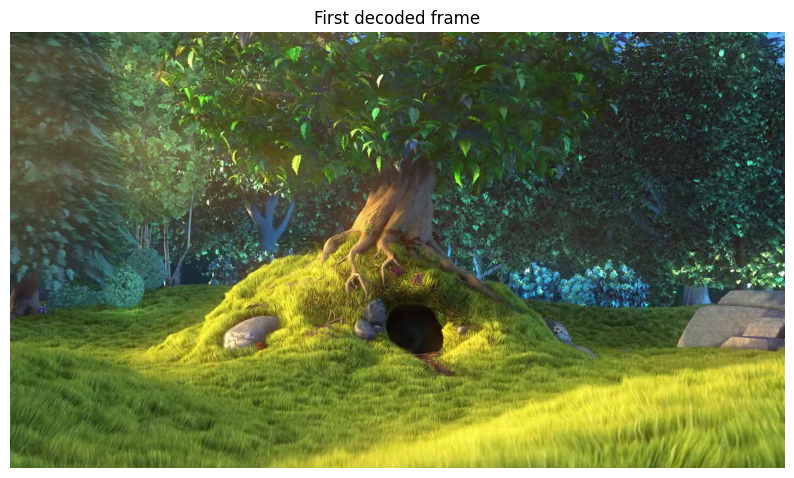

Frame shape: (1080, 1920, 3)


In [11]:
capture = cv2.VideoCapture(str(VIDEO_PATH))
success, first_frame_bgr = capture.read()

first_frame_rgb = cv2.cvtColor(
    first_frame_bgr, cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 7))
plt.imshow(first_frame_rgb)
plt.title("First decoded frame")

plt.axis("off")
plt.show()

print("Frame shape:", first_frame_bgr.shape)

**Benchmark function**

In [12]:
VALID_MODES = {
    "decode_only",
    "decode_overlay",
    "decode_overlay_write",
}


def run_video_pipeline(video_path, mode, output_path=None):
    capture = cv2.VideoCapture(str(video_path))
    
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    source_fps = float(capture.get(cv2.CAP_PROP_FPS))
    reported_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if mode == "decode_overlay_write":
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(
            str(output_path), fourcc,
            source_fps, (width, height)
        )
        
    
    frame_latencies_ms = []
    processed_frames = 0
    total_start = perf_counter()
    
    while True:
        frame_start = perf_counter()
        success, frame = capture.read()
        
        if not success:
            break
        if frame is None or frame.size == 0:
            break
            
        timestamp_seconds = processed_frames / source_fps
        
        if mode in {
            "decode_overlay",
            "decode_overlay_write"
        }:
            overlay_text = (
                f"Frame: {processed_frames}  "
                f"Time: {timestamp_seconds:.2f} s"
            )

            cv2.putText(
                frame, overlay_text, (25, 45),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                (0, 255, 0), 2, cv2.LINE_AA
            )
        
        
        if writer is not None:
            writer.write(frame)
        
        frame_end = perf_counter()
        frame_latencies_ms.append(
            (frame_end - frame_start) * 1000
        )
        
        processed_frames += 1
    
    total_seconds = perf_counter() - total_start
    capture.release()
    
    if writer is not None:
        writer.release()

    if processed_frames == 0:
        raise RuntimeError(
            f"No frames processed in mode: {mode}"
        )

    processing_fps = processed_frames / total_seconds
    mean_latency_ms = float(np.mean(frame_latencies_ms))

    p95_latency_ms = float(
        np.percentile(frame_latencies_ms, 95)
    )

    frame_difference = (
        processed_frames - reported_frames
        if reported_frames > 0
        else np.nan
    )

    return {
        "mode": mode,
        "processed_frames": processed_frames,
        "reported_frames": reported_frames,
        "frame_difference": frame_difference,
        "total_seconds": total_seconds,
        "mean_latency_ms":mean_latency_ms,
        "p95_latency_ms": p95_latency_ms,
        "processing_fps": processing_fps,
        "source_fps": source_fps,
        "real_time_factor": processing_fps / source_fps
    }